# 3.5 Visualizing Relationships in Space and Time Lab

## Dataset
For this lab, I used **`yelp_subset.csv`**, a provided subset of Yelp business and review data. The dataset contains both **spatial information** and **time-series information**, which makes it appropriate for this assignment.

### Relevant features used
- **date**: the review date
- **city** and **state**: location fields
- **latitude** and **longitude**: geographic coordinates
- **stars**: review rating
- **review_count**: business review count

This dataset works well for the lab because it allows me to analyze how review activity and average ratings change across **different places** and **over time**.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")

df = pd.read_csv('../../Lab/yelp_subset.csv')
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

df.head()


,review_id,user_id,business_id,date,text,useful,funny,cool,name,neighborhood,...,city,state,postal_code,latitude,longitude,stars,review_count,is_open,categories,year
0,zsbVXbCsycrTWkVlsKsVOg,u3NDqJr25UwYeXZypxJcqw,xBkXnzbctPGWG86L27GNFQ,2015-01-03,We brought our Doxie to Dr. Scholten for serio...,0,0,1,"""Hopi Animal Hospital""",NaN,...,Scottsdale,AZ,85254,33.639916,-111.961780,4.5,30,1,Pet Services;Pet Sitting;Pets;Veterinarians,2015
1,d3iCvvJsJZs4U-ZFfq_pSA,DxHP0hTWS9Jpd-xSVCMYAg,JDjOobEd_Tm6Z06YRmWkbg,2008-05-13,"First, I'm a regular here. Sunday afternoons a...",5,3,5,"""Charlie's""",NaN,...,Phoenix,AZ,85013,33.508967,-112.083610,3.0,158,1,Bars;Nightlife;Dance Clubs;Gay Bars,2008
2,yTS2FOyhmRHgwAXSG8muiQ,-aYO8Ga4U5hrwxV7y1IaiA,qiRyyRWt6jmAxcoVW0-WHA,2015-08-02,"Best AYCE in Mississauga. For an AYCE, their s...",6,0,1,"""Heart Sushi""",East Credit,...,Mississauga,ON,L5V 2X8,43.610533,-79.698421,3.5,278,1,Chinese;Japanese;Buffets;Restaurants;Sushi Bars,2015
3,W1PG83hPCogZdLlstltWZw,EJLsnsI53YKBHq9te2KSiQ,t67GMPZ0cv_ItKlID-JFiQ,2013-04-10,"Love it! It's a nice quick, inexpensive & tast...",0,1,0,"""Banzo""",NaN,...,Madison,WI,53704,43.101672,-89.364595,4.5,286,1,Food;Mediterranean;Food Trucks;Restaurants,2013
4,Q8IuYiUzeK-Uc8mK-luL3w,gknq0IAq9jaSlotJ465FGw,6P-JmU0VW-qhYq7It1wowg,2014-11-10,Dont eat here! Doesnt even taste like pho here...,0,0,0,"""Pho 68""",NaN,...,Chandler,AZ,85224,33.336151,-111.874338,3.5,77,0,Vietnamese;Restaurants,2014


## Initial interpretation

The Yelp subset contains review-level observations with both spatial fields (**city, state, latitude, longitude**) and a time field (**date**). Other useful features include **stars**, **review_count**, **categories**, and business identity fields. That makes it a strong fit for a space and time visualization lab.


In [2]:
df[['date', 'city', 'state', 'latitude', 'longitude', 'stars', 'review_count']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          2000 non-null   datetime64[ns]
 1   city          2000 non-null   object        
 2   state         2000 non-null   object        
 3   latitude      2000 non-null   float64       
 4   longitude     2000 non-null   float64       
 5   stars         2000 non-null   float64       
 6   review_count  2000 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(1), object(2)
memory usage: 109.5+ KB


## Visualization 1: Review volume by year and state

This first visualization shows how the **number of reviews** changes over time for the five states/provinces with the most records in the dataset.


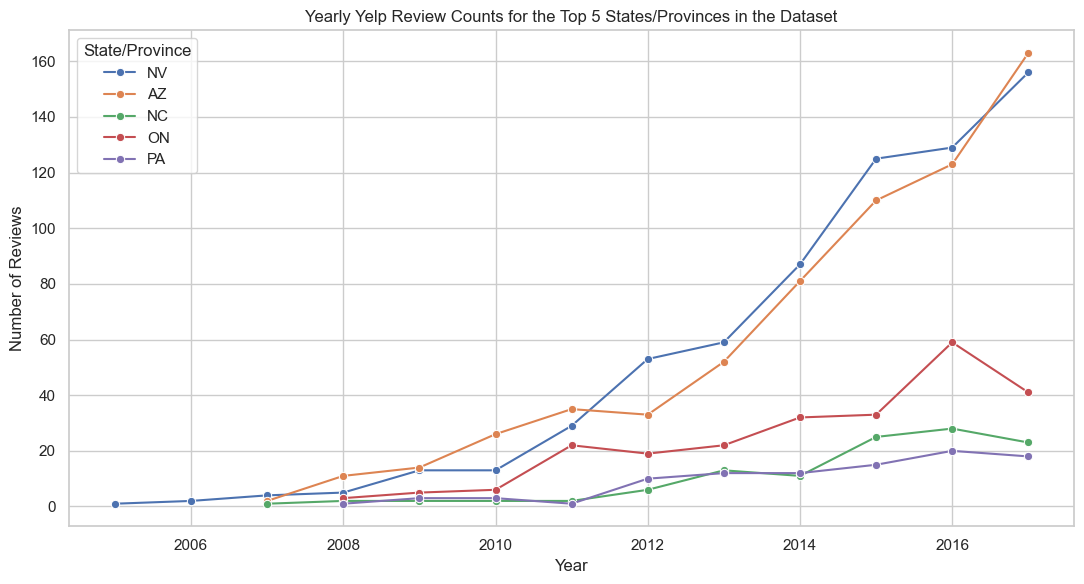

,year,state,review_count
0,2005,NV,1
1,2006,NV,2
2,2007,AZ,2
3,2007,NC,1
4,2007,NV,4


In [3]:
top_states = df['state'].value_counts().head(5).index.tolist()

yearly_reviews = (
    df[df['state'].isin(top_states)]
    .groupby(['year', 'state'])
    .size()
    .reset_index(name='review_count')
)

plt.figure(figsize=(11, 6))
sns.lineplot(data=yearly_reviews, x='year', y='review_count', hue='state', marker='o')
plt.title('Yearly Yelp Review Counts for the Top 5 States/Provinces in the Dataset')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.legend(title='State/Province')
plt.tight_layout()
plt.show()

yearly_reviews.head()


### Interpretation 1

For review volume, the heaviest activity in this subset comes from **NV, AZ, ON, NC, PA**. Among those locations, the single highest yearly review count in the filtered data occurs in **AZ during 2017**.

Overall, the line chart suggests that review activity is not evenly distributed across space. A small number of locations dominate the dataset, and several of them show stronger review activity in later years, which suggests growing participation or denser coverage over time.


## Visualization 2: Average star rating by year and state

This heatmap compares **average ratings** across the same high volume states/provinces over time.


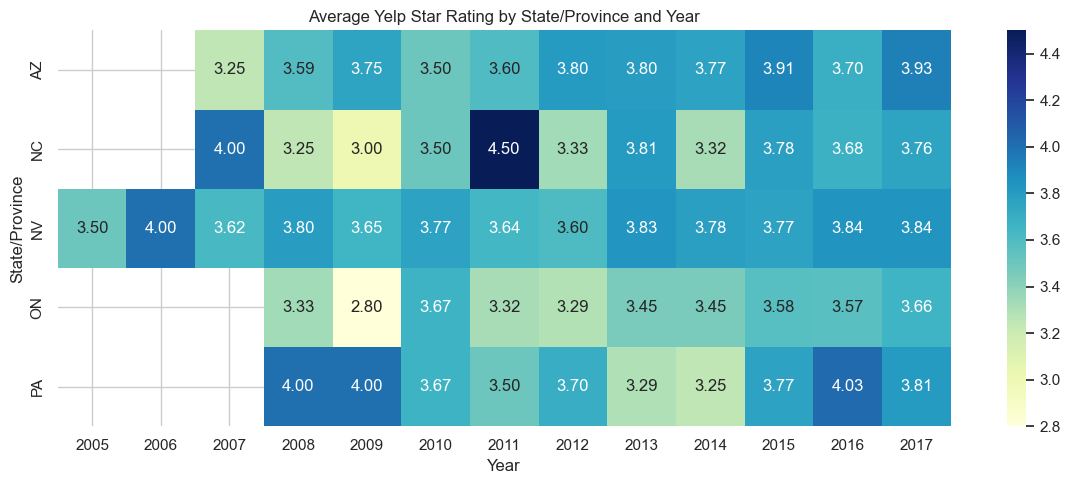

,year,state,stars
0,2005,NV,3.500
1,2006,NV,4.000
2,2007,AZ,3.250
3,2007,NC,4.000
4,2007,NV,3.625


In [4]:
avg_stars = (
    df[df['state'].isin(top_states)]
    .groupby(['year', 'state'])['stars']
    .mean()
    .reset_index()
)

heatmap_data = avg_stars.pivot(index='state', columns='year', values='stars')

plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Average Yelp Star Rating by State/Province and Year')
plt.xlabel('Year')
plt.ylabel('State/Province')
plt.tight_layout()
plt.show()

avg_stars.head()


### Interpretation 2

For average rating, the highest state year average among the selected locations appears in **NC in 2011**, although average star values stay within a relatively narrow band overall.

Compared with review volume, the average rating changes more gradually. That suggests the strongest pattern over time is the **amount of review activity**, while the rating levels themselves remain fairly stable from place to place and year to year.


## Visualization 3: Geographic distribution of review activity over time

For the third visualization, I summarized the data by **city and year** and plotted it on a geographic map. Bubble size represents the number of reviews in that city-year combination, and color represents the average star rating.


In [5]:
city_year = (
    df.groupby(['year', 'city', 'state', 'latitude', 'longitude'])
      .agg(
          review_count=('review_id', 'count'),
          avg_stars=('stars', 'mean')
      )
      .reset_index()
)

top_cities = (
    city_year.groupby(['city', 'state'])['review_count']
    .sum()
    .sort_values(ascending=False)
    .head(12)
    .reset_index()[['city', 'state']]
)

city_year_top = city_year.merge(top_cities, on=['city', 'state'])

fig = px.scatter_geo(
    city_year_top,
    lat='latitude',
    lon='longitude',
    size='review_count',
    color='avg_stars',
    hover_name='city',
    animation_frame='year',
    scope='north america',
    title='Top City Review Activity Over Time',
    size_max=35
)

fig.show()


### Interpretation 3

At the city level, the largest city year review cluster in the top city subset is **Las Vegas, NV in 2008**.

This visualization makes the spatial pattern the clearest. Review activity clusters in major metro areas and stays concentrated in the same general parts of North America across time, while the size of those city level clusters changes from year to year.


## Conclusion

The Yelp subset was a strong choice for this lab because it includes both:
- **time series data** through the review dates
- **spatial data** through states, cities, and geographic coordinates

Across the three visualizations, the clearest overall trend is that **review volume varies more strongly across time and place than average rating does**. In other words, where and when reviews are written changes noticeably, while the ratings themselves are more stable.
